In [4]:
from sklearn.datasets import load_iris

iris_raw = load_iris()


<div style="background-color: #E0F2F1; padding: 12px 20px; margin: 15px 0px; border-radius: 6px; border-left: 5px solid #008B8B;">
    <h3 style="color: #004D40; margin: 0; font-weight: bold;">
        STEP 1: PANDAS - Data ko Sundar Table me Load Karna
    </h3>
</div>


In [8]:
import pandas as pd

df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
df['Species_Name'] = [iris_raw.target_names[i] for i in iris_raw.target  ]
df['Target_Code'] = iris_raw.target
print("=" * 60)
print("📌 STEP 1: PANDAS - DATASET KA EK SAMPLE DEKHEIN")
print("=" * 60)
print(df.head(3))  # Shuruat ki 3 rows
print("\nPhoolon ki kul sankhya (Total Rows):", len(df))

📌 STEP 1: PANDAS - DATASET KA EK SAMPLE DEKHEIN
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   

  Species_Name  Target_Code  
0       setosa            0  
1       setosa            0  
2       setosa            0  

Phoolon ki kul sankhya (Total Rows): 150


<div style="background-color: #E0F2F1; padding: 12px 20px; margin: 15px 0px; border-radius: 6px; border-left: 5px solid #008B8B;">
    <h3 style="color: #004D40; margin: 0; font-weight: bold;">
        STEP 2: NUMPY & SKLEARN - Data Tayyar aur Split Karna
    </h3>
</div>


In [36]:
import numpy as np
from sklearn.model_selection import train_test_split 
# Fetures(input) aur Labels (Output) ko numpy array me badlna
X = df[iris_raw.feature_names].to_numpy()
y = df['Target_Code'].to_numpy()
# data ko 80% training or 20% Testing me baantna 
# ?Query here what is size and state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\n" + "=" * 60)
print("📌 STEP 2: DATA DIVISION (TRAIN VS TEST)")
print("=" * 60)
print(f"Training ke liye data(80%): {X_train.shape[0]} phool")
print(f"Testing ke liye data(20%): {X_test.shape[0]} phool")


📌 STEP 2: DATA DIVISION (TRAIN VS TEST)
Training ke liye data(80%): 120 phool
Testing ke liye data(20%): 30 phool


<div style="background-color: #E0F2F1; padding: 12px 20px; margin: 15px 0px; border-radius: 6px; border-left: 5px solid #008B8B;">
    <h3 style="color: #004D40; margin: 0; font-weight: bold;">
        STEP 3: SKLEARN - Brain (Model) ko Train Karna aur Predict Karna
    </h3>
</div>


In [37]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train,  y_train) # Training run on here...

#model exam on test data
y_pred = model.predict(X_test)
print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


<div style="background-color: #E0F2F1; padding: 12px 20px; margin: 15px 0px; border-radius: 6px; border-left: 5px solid #008B8B;">
    <h3 style="color: #004D40; margin: 0; font-weight: bold;">
        STEP 4: NUMPY - Model ki Galtiyan Dhundna
    </h3>
</div>


In [26]:
from sklearn.metrics import classification_report
print("\n" + "=" * 60)
print("📌 STEP 3 & 4: SKLEARN & NUMPY - EXAM RESULTS")
print("=" * 60)
#Numpy se compare krna ki kaha galati hui hai prediction me
galtiyan = np.where(y_test != y_pred)[0]
if len(galtiyan) == 0:
    print("🎉 Kamaal ho gaya! Model ne saare jawabein 100% sahi diyan.")
else:
    print(f"Model ne kul {len(galtiyan)} phool galat pehchane.")
    for idx in galtiyan:
        # ?Expalin bellow lines
        asli = iris_raw.target_names[y_pred[idx]]
        model_ka_guess = iris_raw.target_names[y_pred[idx]]
        print(
            f"   - index {idx} par: Asli phool '{asli}' tha, per model ne use '{model_ka_guess}' samajh liya."
        )

# Detailed Report (Precision, Recall, F1-Score)

print("\n📊 DETAILED PERFORMANCE REPORT:") 
print(
    classification_report(
        y_test, y_pred, target_names=iris_raw.target_names, zero_division=0 
    )
)


📌 STEP 3 & 4: SKLEARN & NUMPY - EXAM RESULTS
🎉 Kamaal ho gaya! Model ne saare jawabein 100% sahi diyan.

📊 DETAILED PERFORMANCE REPORT:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



<div style="background-color: #E0F2F1; padding: 12px 20px; margin: 15px 0px; border-radius: 6px; border-left: 5px solid #008B8B;">
    <h3 style="color: #004D40; margin: 0; font-weight: bold;">
        STEP 5: MATPLOTLIB - Model ka Dimaag Graph me Dekhna
    </h3>
</div>



📌 STEP 5: MATPLOTLIB - VISUALIZATION GRAPH POP-UP HOGA
Graph window ko dekhein jo abhi screen par khulegi...


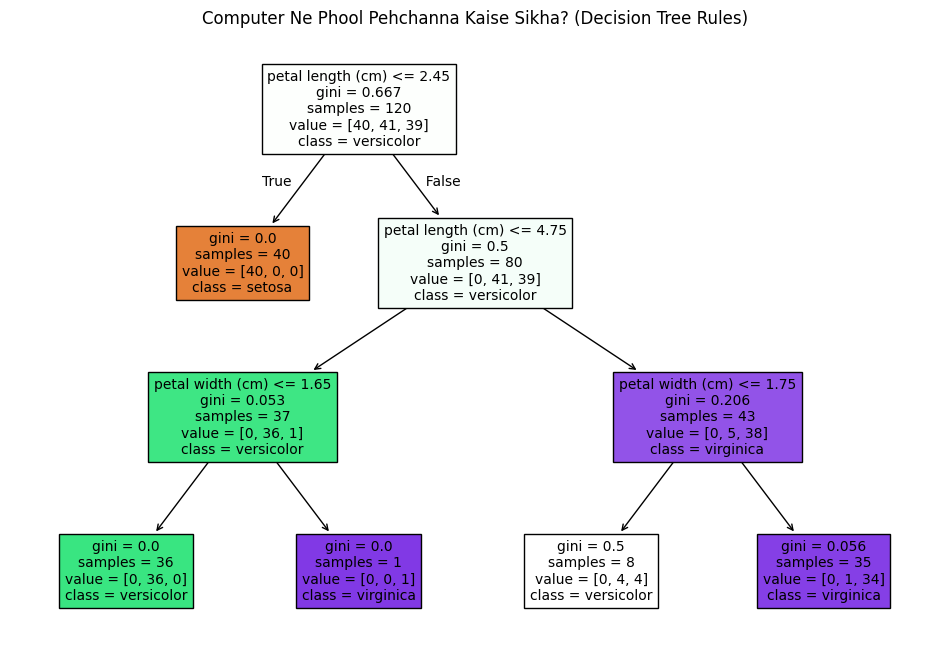

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
print("\n" + "=" * 60)
print("📌 STEP 5: MATPLOTLIB - VISUALIZATION GRAPH POP-UP HOGA")
print("=" * 60)
print("Graph window ko dekhein jo abhi screen par khulegi...")

plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=iris_raw.feature_names,
    class_names=list(iris_raw.target_names),
    filled=True,
    fontsize=10
)
plt.title("Computer Ne Phool Pehchanna Kaise Sikha? (Decision Tree Rules)")
plt.show()